# LondonPulse: seven days of a city's rhythm

## tl;dr

**A simple linear model earns its place.** Ridge regression forecasts aggregate London cycle hires with **2,870.58 hires/day MAE** across **86 held-out weeks (602 daily forecasts)**. That is **19.7% lower error** than repeating the previous week's weekday, and lower error than the tested nonlinear model. The model was selected on 2023 validation weeks before the 2025–2026 test was scored.

Nominal 90% daily ranges cover **543/602 outcomes (90.2%)**, with a mean width of **12,667 hires/day**. Their overall coverage hides a weaker day-3/Wednesday result, and time dependence prevents a guaranteed coverage claim.

This notebook independently audits the shipped forecast rows, chronology, features and ranges. It uses genuine TfL observations through **31 August 2026**. The app's September outlook is a saved historical snapshot, not today's live forecast.


## Context & Methods

The question is whether recent observed counts and known calendar patterns improve a seven-day forecast of **completed, city-wide cycle hires**. The target is not unique riders, unmet demand or station-level bicycle availability. Each origin is the end of a day whose count is available; horizons 1–7 refer to the following seven dates.

Targets in **2015–2022** fit candidate models. Complete Sunday-origin weeks in **2023** select a family and configuration using mean absolute error (MAE). Fitted families are then refitted through **31 December 2023**. **2024** weeks calibrate daily ranges, and **2025–30 August 2026** weeks form the final test. The model and radii stay fixed through the test. Recent observations become available at each origin without being used to refit the model.

### Key Assumptions

- Thirty-five consecutive observed days supply causal count features. Future dates supply calendar features; actual future weather, future counts and retrospective event labels do not enter the model.
- The experiment uses one revised October 2026 source snapshot, not the original publication vintage at each historical origin. Source revisions can make these counts differ slightly from those available then; this is a retrospective backtest, not a reconstruction of every original release.
- Evaluation weeks have non-overlapping targets, but origins share history. Fitting uses overlapping daily origins and repeated target dates. These are temporally dependent observations, not independent trials.
- Sunday origins align horizon 1 with Monday and horizon 7 with Sunday. Horizon and weekday effects cannot be separated in this experiment.
- Calibration ranges are empirical per-day bands. They are not guaranteed probabilities for particular days, whole weeks or weekly totals.
- Calibration and evaluation use Sunday origins. The illustrative 31 August 2026 origin is a Monday, whose interval coverage has not been separately assessed, although the point model was fitted with daily origins.

The [methods](../docs/methods.md), [model card](../docs/model-card.md) and [data licence](../DATA_LICENSE.md) retain details. Python 3.12 and the repository's dependencies reproduce this notebook. Run from the repository root or its `notebooks` folder; all audit inputs are tracked and require no network access.


In [1]:
from pathlib import Path
import hashlib
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter, PercentFormatter
from IPython.display import display

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if not (REPO / "artifacts" / "results.json").exists():
    raise FileNotFoundError("Run this notebook from the LondonPulse repository or its notebooks folder.")
sys.path.insert(0, str(REPO / "src"))
FIGURES = REPO / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
results = json.loads((REPO / "artifacts" / "results.json").read_text(encoding="utf-8"))
provenance = json.loads((REPO / "data" / "processed" / "provenance.json").read_text(encoding="utf-8"))
splits = json.loads((REPO / "artifacts" / "splits.json").read_text(encoding="utf-8"))
daily = pd.read_csv(REPO / "data" / "processed" / "daily.csv", parse_dates=["date"])
tables = {name: pd.read_csv(REPO / "artifacts" / f"{name}_forecasts.csv", parse_dates=["origin", "date"])
          for name in ("validation", "calibration", "test")}
test = tables["test"]

BLUE, GOLD, INK, GREY = "#1c6e8c", "#b87d22", "#243342", "#cbd2d9"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#7c8792",
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white"})

def tidy_axis(ax, axis="y"):
    ax.grid(axis=axis, color="#e4e8ec", linewidth=0.7)
    ax.set_axisbelow(True)

def save_figure(fig, filename):
    fig.savefig(FIGURES / filename, dpi=160, bbox_inches="tight")
    plt.show()


## Data

### Validate the daily observation grain

Source: [Transport for London, Number of Bicycle Hires, London Datastore](https://data.london.gov.uk/dataset/number-of-bicycle-hires-2r84d), under [Open Government Licence v2.0](https://www.nationalarchives.gov.uk/doc/open-government-licence/version/2/). The pinned workbook was retrieved on 5 October 2026. Only its daily date/count columns were extracted. SHA-256 provenance identifies the original workbook and the processed CSV.

The workbook's metadata sheet retains an August 2025 end date while its daily observations and the source catalogue extend to August 2026. The daily dates determine coverage. The publisher documents a scheme shutdown on 10–11 September 2022 and records zeros; these are preserved but do not indicate zero underlying demand. Delayed events may revise daily counts, which usually stabilise after two weeks.


In [2]:
assert hashlib.sha256((REPO / "data" / "processed" / "daily.csv").read_bytes()).hexdigest() == provenance["processed_sha256"]
assert hashlib.sha256((REPO / "models" / "model.joblib").read_bytes()).hexdigest() == results["model_sha256"]
assert daily.date.is_monotonic_increasing and not daily.date.duplicated().any()
assert daily.date.diff().dropna().eq(pd.Timedelta(days=1)).all()
assert daily.hires.notna().all() and np.isfinite(daily.hires).all()
assert daily.hires.ge(0).all() and np.equal(daily.hires, np.floor(daily.hires)).all()
assert len(daily) == provenance["quality"]["calendar_rows"] == 5877
assert int(daily.hires.sum()) == provenance["quality"]["total_hires"] == 154053134
zero_dates = daily.loc[daily.hires.eq(0), "date"].dt.strftime("%Y-%m-%d").tolist()
assert zero_dates == ["2022-09-10", "2022-09-11"]
source_summary = pd.DataFrame({"Measure": ["First observation", "Last observation", "Daily observations",
    "Missing counts", "Duplicated dates", "Total recorded hires", "Publisher-reported zero days"],
    "Value": [daily.date.min().strftime("%d %B %Y"), daily.date.max().strftime("%d %B %Y"),
    f"{len(daily):,}", int(daily.hires.isna().sum()), int(daily.date.duplicated().sum()),
    f"{int(daily.hires.sum()):,}", len(zero_dates)]})
display(source_summary.style.hide(axis="index"))


Measure,Value
First observation,30 July 2010
Last observation,31 August 2026
Daily observations,"5,877"
Missing counts,0
Duplicated dates,0
Total recorded hires,"154,053,134"
Publisher-reported zero days,2


### Read the record at a useful scale

Monthly mean daily counts provide context without mixing monthly totals with daily targets. July 2010 contains only the two opening days; the final month is complete in the source. The plot describes movement in recorded hires; it does not attribute changes to a cause.


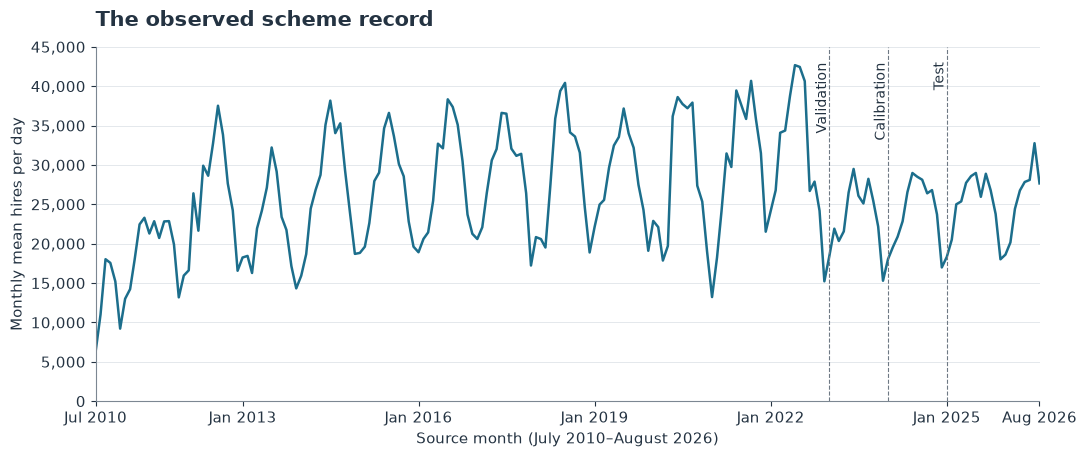

In [3]:
monthly_source = daily.set_index("date").hires.resample("MS").mean()
fig, ax = plt.subplots(figsize=(11, 4.7))
ax.plot(monthly_source.index, monthly_source, color=BLUE, linewidth=1.8)
for date, label in [("2023-01-01", "Validation"), ("2024-01-01", "Calibration"), ("2025-01-01", "Test")]:
    ax.axvline(pd.Timestamp(date), color="#6e7984", linestyle="--", linewidth=0.8)
    ax.text(pd.Timestamp(date), 43000, label, rotation=90, va="top", ha="right", fontsize=10)
ticks = [monthly_source.index[0]] + list(pd.date_range("2013-01-01", "2025-01-01", freq="3YS")) + [monthly_source.index[-1]]
ax.set_xticks(ticks, [d.strftime("%b %Y") for d in ticks])
ax.set_xlim(monthly_source.index[0], monthly_source.index[-1])
ax.set_ylim(0, 45000)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set(xlabel="Source month (July 2010–August 2026)", ylabel="Monthly mean hires per day")
ax.set_title("The observed scheme record", loc="left", pad=15)
tidy_axis(ax)
fig.tight_layout()
save_figure(fig, "source-history.png")


### Check chronological partitions and target identity

Each evaluation export contains complete Sunday-origin weeks. Every target count is reconciled to its date in the processed source. Validation, calibration and test targets are disjoint, with calibration later than final fitting. Full seven-day weeks omit partial boundary periods.


In [4]:
counts = daily.set_index("date").hires
split_rows = []
previous_targets = set()
for name in ("validation", "calibration", "test"):
    table = tables[name]
    assert table.origin.dt.dayofweek.eq(6).all()
    assert (table.date - table.origin).dt.days.eq(table.horizon).all()
    assert table.date.gt(table.origin).all()
    assert not table.date.duplicated().any()
    assert not table.duplicated(["origin", "horizon"]).any()
    assert table.groupby("origin").horizon.apply(lambda s: sorted(s.tolist()) == list(range(1, 8))).all()
    assert np.array_equal(counts.loc[table.date].to_numpy(), table.actual.to_numpy())
    targets = set(table.date)
    assert not previous_targets.intersection(targets)
    previous_targets.update(targets)
    info = splits[name]
    assert len(table) == info["rows"] and table.origin.nunique() == info["origins"]
    assert str(table.date.min().date()) == info["target_start"]
    assert str(table.date.max().date()) == info["target_end"]
    split_rows.append({"Partition": name.title(), "Weeks": table.origin.nunique(), "Days": len(table),
        "First target": table.date.min().strftime("%d %b %Y"), "Last target": table.date.max().strftime("%d %b %Y")})
assert pd.Timestamp(splits["fit"]["target_end"]) < tables["validation"].date.min()
assert pd.Timestamp(splits["refit"]["target_end"]) < tables["calibration"].date.min()
assert tables["calibration"].date.max() < tables["test"].date.min()
assert tables["validation"].origin.nunique() == 52
assert tables["calibration"].origin.nunique() == 51
assert tables["test"].origin.nunique() == 86
display(pd.DataFrame(split_rows).style.hide(axis="index"))


Partition,Weeks,Days,First target,Last target
Validation,52,364,02 Jan 2023,31 Dec 2023
Calibration,51,357,08 Jan 2024,29 Dec 2024
Test,86,602,06 Jan 2025,30 Aug 2026


### Test the causal feature boundary

The count-derived features must stop at the origin. The checks below reconstruct lagged and rolling values directly from source counts for every test forecast row, then check that truncating or changing observations after a probe origin cannot change that origin's seven feature rows.


In [5]:
from londonpulse.features import FEATURE_COLUMNS, build_features, temporal_partitions

features = build_features(daily)
feature_rows = features.set_index(["origin", "horizon"])
for row in test.itertuples():
    values = feature_rows.loc[(row.origin, row.horizon)]
    assert values.date == row.date
    assert np.isclose(values.origin_hires, counts.loc[row.origin])
    for lag in (1, 7, 14, 28):
        assert np.isclose(values[f"lag_{lag}"], counts.loc[row.origin - pd.Timedelta(days=lag)])
    for window in (7, 28):
        trailing = counts.loc[row.origin - pd.Timedelta(days=window - 1):row.origin].to_numpy()
        assert np.isclose(values[f"rolling_{window}_mean"], trailing.mean())
        assert np.isclose(values[f"rolling_{window}_std"], trailing.std(ddof=0))
    current_week = counts.loc[row.origin - pd.Timedelta(days=6):row.origin].mean()
    preceding_week = counts.loc[row.origin - pd.Timedelta(days=13):row.origin - pd.Timedelta(days=7)].mean()
    assert np.isclose(values.week_change, current_week - preceding_week)
    weekday_dates = [row.date - pd.Timedelta(days=7 * k) for k in range(1, 5)]
    assert max(weekday_dates) <= row.origin
    weekdays = counts.loc[weekday_dates].to_numpy()
    assert np.isclose(values.target_weekday_last, weekdays[0])
    assert np.isclose(values.target_weekday_mean_4, weekdays.mean())
    assert np.isclose(values.target_weekday_std_4, weekdays.std(ddof=0))

probe = pd.Timestamp("2024-06-30")
full = build_features(daily, include_targets=False).query("origin == @probe")[FEATURE_COLUMNS].reset_index(drop=True)
prefix = build_features(daily.loc[daily.date.le(probe)], include_targets=False).query("origin == @probe")[FEATURE_COLUMNS].reset_index(drop=True)
changed_daily = daily.copy()
changed_daily.loc[changed_daily.date.gt(probe), "hires"] += 100000
changed = build_features(changed_daily, include_targets=False).query("origin == @probe")[FEATURE_COLUMNS].reset_index(drop=True)
pd.testing.assert_frame_equal(full, prefix)
pd.testing.assert_frame_equal(full, changed)
partitions = temporal_partitions(features)
assert len(partitions["fit"]) == splits["fit"]["rows"] == 20454
assert len(partitions["refit"]) == splits["refit"]["rows"] == 23009
assert len(FEATURE_COLUMNS) == 21
print("Verified 602 forecast rows against their source history; future truncation and perturbation leave all seven probe forecasts' features unchanged.")


Verified 602 forecast rows against their source history; future truncation and perturbation leave all seven probe forecasts' features unchanged.


## Results

### Recalculate the selection and final scores

The functions below implement the formulas directly, without using the project's scoring helper. MAE and RMSE are hires per day. WAPE divides total absolute error by total observed hires; sMAPE averages symmetric daily percentage errors. Lower values are better. The validation scores describe the pre-refit models; final test scores describe each family's refitted model.


In [6]:
def independent_scores(actual, prediction):
    y, p = np.asarray(actual, dtype=float), np.asarray(prediction, dtype=float)
    error = p - y
    denominator = np.abs(y) + np.abs(p)
    terms = np.divide(2 * np.abs(error), denominator, out=np.zeros_like(error), where=denominator > 0)
    return {"mae": float(np.abs(error).mean()), "rmse": float(np.sqrt(np.square(error).mean())),
        "wape": float(100 * np.abs(error).sum() / np.abs(y).sum()), "smape": float(100 * terms.mean())}

score_rows = []
for exported in results["models"]:
    identifier = exported["id"]
    recalculated = independent_scores(test.actual, test[identifier])
    for metric, value in recalculated.items():
        assert np.isclose(value, exported[metric], rtol=1e-10, atol=1e-7)
    validation_mae = independent_scores(tables["validation"].actual, tables["validation"][identifier])["mae"]
    assert np.isclose(validation_mae, exported["validation_mae"], atol=1e-7)
    score_rows.append({"Model": exported["name"], "ID": identifier, "Validation MAE": validation_mae,
        "Test MAE": recalculated["mae"], "Test RMSE": recalculated["rmse"],
        "Test WAPE (%)": recalculated["wape"], "Test sMAPE (%)": recalculated["smape"]})
scores = pd.DataFrame(score_rows)
selected = scores.loc[scores["Validation MAE"].idxmin(), "ID"]
assert selected == results["overview"]["selected_model"] == "ridge"
assert np.allclose(test.prediction, test[selected])
selected_scores = independent_scores(test.actual, test.prediction)
for metric, value in selected_scores.items():
    assert np.isclose(value, results["overview"][metric], atol=1e-7)
improvement = 100 * (1 - selected_scores["mae"] / independent_scores(test.actual, test.seasonal_naive)["mae"])
assert np.isclose(improvement, results["overview"]["baseline_improvement_percent"])
display(scores.drop(columns="ID").style.hide(axis="index").format({column: "{:,.2f}" for column in scores.columns if column not in ("ID", "Model")}))


Model,Validation MAE,Test MAE,Test RMSE,Test WAPE (%),Test sMAPE (%)
"Previous week, same weekday","3,589.56","3,573.01","5,038.60",14.08,16.07
Four-week weekday mean,"3,434.00","3,376.68","4,673.52",13.31,14.81
Ridge regression,"3,178.12","2,870.58","3,984.85",11.31,12.60
Histogram gradient boosting,"3,560.54","3,194.12","4,087.75",12.59,13.58


### Compare useful baselines with the selected model

The previous-week and four-week weekday baselines set a meaningful standard. Ridge uses the same causal feature set as histogram gradient boosting. The comparison below uses all 602 final test forecasts; the zero baseline on the axis preserves the size of the difference.


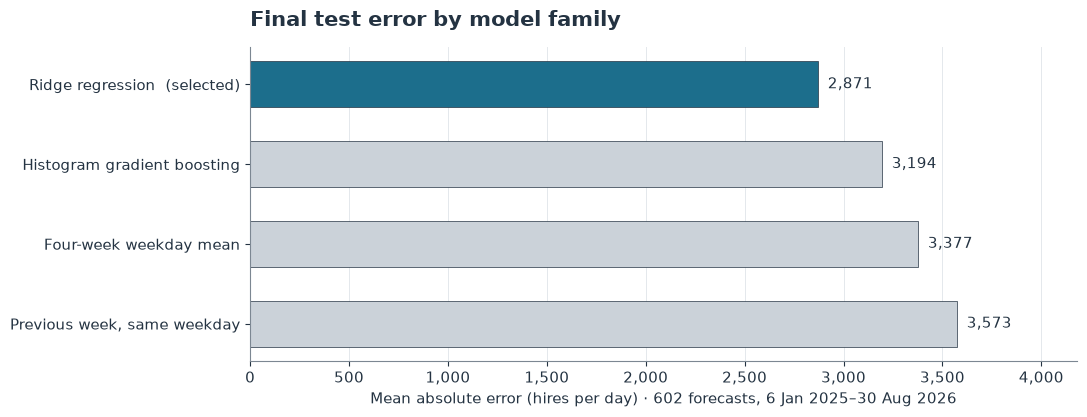

In [7]:
ordered = scores.sort_values("Test MAE", ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 4.3))
positions = np.arange(len(ordered))
colours = [BLUE if identifier == selected else GREY for identifier in ordered.ID]
ax.barh(positions, ordered["Test MAE"], color=colours, height=0.58, edgecolor=INK, linewidth=0.5)
for position, value in zip(positions, ordered["Test MAE"]):
    ax.text(value + 50, position, f"{value:,.0f}", va="center", fontsize=11)
labels = [f"{name}  (selected)" if identifier == selected else name for name, identifier in zip(ordered.Model, ordered.ID)]
ax.set_yticks(positions, labels)
ax.set_xlim(0, ordered["Test MAE"].max() * 1.17)
ax.set_xlabel("Mean absolute error (hires per day) · 602 forecasts, 6 Jan 2025–30 Aug 2026")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Final test error by model family", loc="left", pad=15)
tidy_axis(ax, "x")
fig.tight_layout()
save_figure(fig, "model-comparison.png")


Ridge's measured MAE is **2,870.58**, versus **3,573.01** for repeating the previous weekday: a **19.7% reduction**. Its validation-selected regularisation is `alpha=100`. The more flexible tree model does not improve the measured MAE or RMSE here. This is evidence for the selected approach on these dates, rather than a claim that linear models always forecast better.


### Reconstruct the daily ranges

There are 51 calibration forecasts per horizon. A nominal 90% target uses the 47th ordered absolute error, separately for each of the seven horizons. Test outcomes never determine a radius. Lower bounds are clipped at zero. Coverage and width are recomputed from the exported bounds, not the stored coverage flag.


In [8]:
calibration = tables["calibration"]
assert np.allclose(calibration.prediction, calibration[selected])
assert np.allclose(abs(calibration.prediction - calibration.actual), calibration.absolute_error)
interval_rows = []
for horizon in range(1, 8):
    cal = calibration.loc[calibration.horizon.eq(horizon)]
    absolute_errors = abs(cal.prediction - cal.actual).to_numpy()
    rank = math.ceil((len(cal) + 1) * 0.90)
    radius = np.sort(absolute_errors)[rank - 1]
    assert len(cal) == 51 and rank == 47
    assert np.isclose(radius, results["diagnostics"]["intervals"]["radii"][str(horizon)])
    assert rank == results["diagnostics"]["intervals"]["finite_ranks"][str(horizon)]
    group = test.loc[test.horizon.eq(horizon)]
    assert np.allclose(group.radius, radius)
    assert np.allclose(group.lower, np.maximum(0, group.prediction - radius))
    assert np.allclose(group.upper, group.prediction + radius)
    interval_rows.append({"Days ahead": horizon, "Calibration forecasts": len(cal), "Ordered rank": rank, "Radius (hires)": radius})
test = test.assign(absolute_error=abs(test.prediction - test.actual),
    checked_coverage=test.actual.between(test.lower, test.upper), width=test.upper - test.lower)
assert np.array_equal(test.checked_coverage.to_numpy(), test.covered.to_numpy())
observed_coverage = float(test.checked_coverage.mean())
mean_width = float(test.width.mean())
assert np.isclose(observed_coverage, results["overview"]["coverage"])
assert np.isclose(mean_width, results["overview"]["mean_interval_width"])
assert int(test.checked_coverage.sum()) == 543
display(pd.DataFrame(interval_rows).style.hide(axis="index").format({"Radius (hires)": "{:,.1f}"}))
display(pd.DataFrame({"Measure": ["Nominal target", "Actual covered daily outcomes", "Actual daily coverage", "Mean daily range width"],
    "Value": ["90%", f"{test.checked_coverage.sum()} / {len(test)}", f"{observed_coverage:.1%}", f"{mean_width:,.1f} hires"]}).style.hide(axis="index"))


Days ahead,Calibration forecasts,Ordered rank,Radius (hires)
1,51,47,"5,781.0"
2,51,47,"6,837.9"
3,51,47,"4,597.7"
4,51,47,"6,934.7"
5,51,47,"6,576.4"
6,51,47,"7,400.0"
7,51,47,"6,208.3"


Measure,Value
Nominal target,90%
Actual covered daily outcomes,543 / 602
Actual daily coverage,90.2%
Mean daily range width,"12,667.5 hires"


### See one complete held-out week

The final complete test week is selected by chronology, not by its error. The forecast is issued on 23 August 2026 for 24–30 August. Seven individual daily ranges show estimate, uncertainty and observed outcome together. They are not confidence intervals for the mean error, nor a calibrated band for a weekly sum.


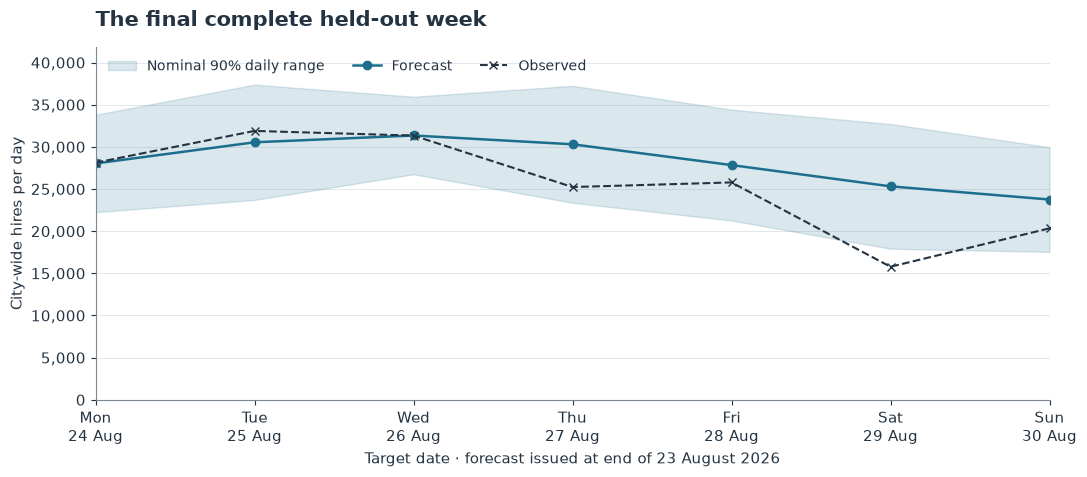

In [9]:
last_origin = test.origin.max()
week = test.loc[test.origin.eq(last_origin)].sort_values("horizon")
fig, ax = plt.subplots(figsize=(11, 4.9))
ax.fill_between(week.date, week.lower, week.upper, color=BLUE, alpha=0.16, label="Nominal 90% daily range")
ax.plot(week.date, week.prediction, color=BLUE, marker="o", linewidth=1.8, label="Forecast")
ax.plot(week.date, week.actual, color=INK, marker="x", linestyle="--", linewidth=1.5, label="Observed")
ax.set_xticks(week.date, [d.strftime("%a\n%d %b") for d in week.date])
ax.set_xlim(week.date.min(), week.date.max())
ax.set_ylim(0, max(week.upper.max(), week.actual.max()) * 1.12)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set(ylabel="City-wide hires per day", xlabel="Target date · forecast issued at end of 23 August 2026")
ax.set_title("The final complete held-out week", loc="left", pad=15)
ax.legend(loc="upper left", ncol=3, frameon=False, fontsize=10)
tidy_axis(ax)
fig.tight_layout()
save_figure(fig, "forecast-week.png")


### Look beyond the headline score

Sunday origins couple each horizon with a weekday. The chart below displays that single grouping rather than implying two independent explanations. All seven groups have the same 86-forecast denominator. A high overall coverage rate can coexist with lower coverage for one horizon.


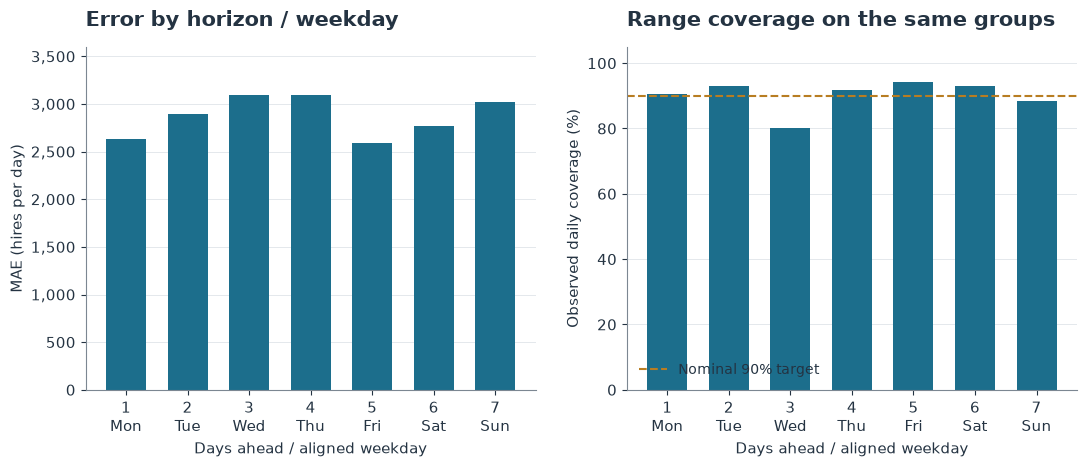

In [10]:
horizon_rows = []
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
for horizon, group in test.groupby("horizon"):
    score = independent_scores(group.actual, group.prediction)
    exported = next(item for item in results["diagnostics"]["by_horizon"] if item["horizon"] == horizon)
    assert all(np.isclose(value, exported[metric]) for metric, value in score.items())
    assert np.isclose(group.checked_coverage.mean(), exported["coverage"])
    weekday = weekday_names[horizon - 1]
    assert group.date.dt.day_name().eq(weekday).all()
    weekday_export = next(item for item in results["diagnostics"]["by_weekday"] if item["weekday"] == weekday)
    assert np.isclose(score["mae"], weekday_export["mae"])
    horizon_rows.append({"Horizon": horizon, "Weekday": weekday, "Forecasts": len(group),
        "MAE": score["mae"], "Coverage": group.checked_coverage.mean()})
horizons = pd.DataFrame(horizon_rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
labels = [f"{h}\n{day[:3]}" for h, day in zip(horizons.Horizon, horizons.Weekday)]
axes[0].bar(horizons.Horizon, horizons.MAE, color=BLUE, width=0.65)
axes[0].set(ylim=(0, 3600), ylabel="MAE (hires per day)", xlabel="Days ahead / aligned weekday")
axes[0].set_title("Error by horizon / weekday", loc="left", pad=15)
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].bar(horizons.Horizon, horizons.Coverage * 100, color=BLUE, width=0.65)
axes[1].axhline(90, color=GOLD, linestyle="--", linewidth=1.5, label="Nominal 90% target")
axes[1].set(ylim=(0, 105), ylabel="Observed daily coverage (%)", xlabel="Days ahead / aligned weekday")
axes[1].set_title("Range coverage on the same groups", loc="left", pad=15)
axes[1].legend(loc="lower left", frameon=False, fontsize=10)
for ax in axes:
    ax.set_xticks(horizons.Horizon, labels)
    tidy_axis(ax)
fig.tight_layout(w_pad=2)
save_figure(fig, "horizon-diagnostics.png")


Day 3/Wednesday ranges cover **69 of 86 outcomes (80.2%)**, compared with 90.2% overall. The third horizon has the smallest calibration radius. This descriptive result exposes a limitation of the frozen per-horizon ranges; it does not identify whether the cause is weekday behaviour, distance from the origin or another change in demand.


### Inspect temporal coverage rather than only an average

Monthly summaries use target dates. The first test month begins on 6 January 2025 and the last ends on 30 August 2026, so these are the evaluated days, not all days in those two months. Small monthly denominators make the percentages coarse. The plot does not attach independent-trial confidence intervals to dependent time-series outcomes.


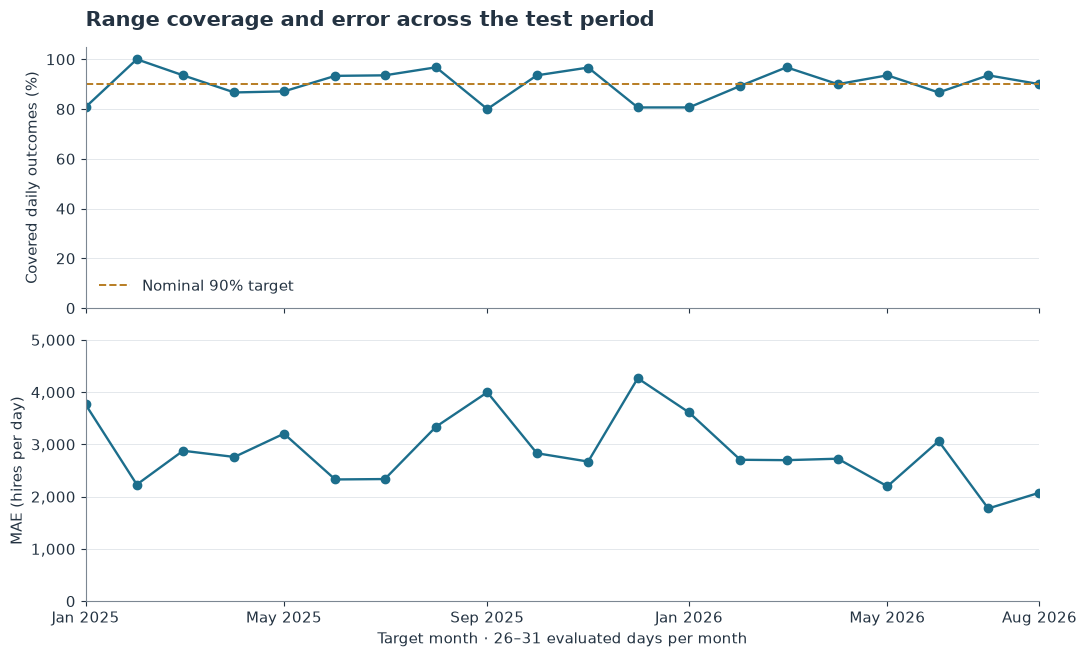

In [11]:
monthly_rows = []
for month, group in test.groupby(test.date.dt.to_period("M")):
    exported = next(item for item in results["diagnostics"]["monthly"] if item["month"] == str(month))
    score = independent_scores(group.actual, group.prediction)
    assert all(np.isclose(value, exported[metric]) for metric, value in score.items())
    assert len(group) == exported["count"]
    assert np.isclose(group.checked_coverage.mean(), exported["coverage"])
    monthly_rows.append({"month": month.to_timestamp(), "coverage": group.checked_coverage.mean(),
        "mae": score["mae"], "count": len(group)})
monthly = pd.DataFrame(monthly_rows)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.7), sharex=True)
axes[0].plot(monthly.month, monthly.coverage * 100, color=BLUE, marker="o", linewidth=1.7)
axes[0].axhline(90, color=GOLD, linestyle="--", linewidth=1.4, label="Nominal 90% target")
axes[0].set(ylim=(0, 105), ylabel="Covered daily outcomes (%)")
axes[0].set_title("Range coverage and error across the test period", loc="left", pad=15)
axes[0].legend(loc="lower left", frameon=False)
axes[1].plot(monthly.month, monthly.mae, color=BLUE, marker="o", linewidth=1.7)
axes[1].set(ylim=(0, 5000), ylabel="MAE (hires per day)", xlabel="Target month · 26–31 evaluated days per month")
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ticks = monthly.month.iloc[[0, 4, 8, 12, 16, 19]]
axes[1].set_xticks(ticks, [d.strftime("%b %Y") for d in ticks])
axes[1].set_xlim(monthly.month.min(), monthly.month.max())
for ax in axes:
    tidy_axis(ax)
fig.tight_layout()
save_figure(fig, "temporal-diagnostics.png")


Monthly range coverage varies from **80% to 100%** on these evaluated dates. The aggregate **90.2%** result is therefore a summary of heterogeneous periods, not proof that each month or day has a 90% chance of being covered. The mean daily width of **12,667 hires** makes the range's cost visible alongside coverage.

## Takeaways

- Ridge's **2,870.58 hires/day MAE** is **19.7% below** the previous-week weekday baseline. The validation-selected linear model also beats the tested nonlinear model on final MAE and RMSE. Extra complexity is not itself a result.
- The daily ranges cover **543/602 outcomes**, but are broad and weaker for day 3/Wednesday. Their empirical calibration does not guarantee future, conditional or simultaneous weekly coverage.
- All four model scores, validation selection, exported truths, chronology, radii, bounds and main diagnostics reconcile with the included artefacts. Lag and rolling features were checked against available source history, with a future-perturbation test at one probe origin.
- Aggregate hires can support a discussion of capacity, but cannot prescribe station redistribution or measure unmet demand. Future weather, bank holidays and events are not explicit features. The saved model can become stale.
- A useful extension would evaluate several predeclared rolling training/calibration windows or add genuinely available weather forecasts and calendar events. It would retain a fresh final test rather than repeatedly tuning to the current one.

**Reproducibility:** this notebook is saved with outputs after a complete top-to-bottom execution. It audits tracked forecast artefacts; from the repository root, `python -m londonpulse.train --project-dir . --skip-download` separately reproduces the fitting and scoring pipeline from the verified, tracked daily snapshot. Contains public sector information licensed under the [Open Government Licence v2.0](https://www.nationalarchives.gov.uk/doc/open-government-licence/version/2/); source: Transport for London via London Datastore.
